**The dataset** includes various independent variables (e.g., engine size, horsepower, fuel type, car body style) and **one dependent** variable (price).

**The Goal** is to:
1. Identify the **key factors** that significantly influence car prices.
2. Build a **linear regression model** to **predict car prices** based on features.

## Import Libraries

In [516]:
# Math :
import numpy as np
import math

# Dataset settings :
import pandas as pd

# Plots :
import matplotlib.pyplot as plt
import seaborn as sns

# Encoding :
from sklearn.preprocessing import LabelEncoder

# Feature Engineering , Polynomial Features
from sklearn.preprocessing import PolynomialFeatures

# PCA : Principal Component Analysis , For Feature Extraction :
from sklearn.decomposition import PCA

# Scalling
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV

from sklearn import metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Read DataSet

In [517]:
data_frame = pd.read_csv('Car_Price_DataSet.csv')

## Explore DataSet

In [518]:
# Shape : (row , column)
print(f'Shape : {data_frame.shape}\n')

# First five rows of data frame
print(f"Head Of Data Frame : \n\n {data_frame.head()}\n")

# Last five rows of data frame
print(f"Tail Of Data Frame : \n\n {data_frame.tail()}\n")

# Columns' names of data frame
print(f"Columns Of Data Frame : \n {data_frame.columns}\n")

# Number of null values in each column in data frame
print(f"Number Of Null Values : \n\n {data_frame.isnull().sum()}\n")

# The whole number of null values in data frame
print(f"The Total Number Of Null Values : {data_frame.isnull().sum().sum()}\n")

# A whole description of some math stuff related to the data frame
print(f"The Description of The Data Frame : \n\n{data_frame.describe()}\n")

Shape : (205, 26)

Head Of Data Frame : 

    car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke comp

## Get Some Info About data size and columns types

In [519]:
print("Data Size & Columns Types Of Data Frame : \n")
data_frame.info()

Data Size & Columns Types Of Data Frame : 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  

## Add Some Plots To Get Information about The Data

In [520]:
  # Categorical Columns
  CCs = data_frame.select_dtypes(include=['object']).columns.to_list()
  print(CCs)
  # Numerical Columns
  NCs = data_frame.select_dtypes(include=['float' , 'int']).columns.to_list()
  print(NCs)

['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']
['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']


**For All Columns :**

**Distribution of the Target Variable: price , to understand the range and common price points of the cars.**

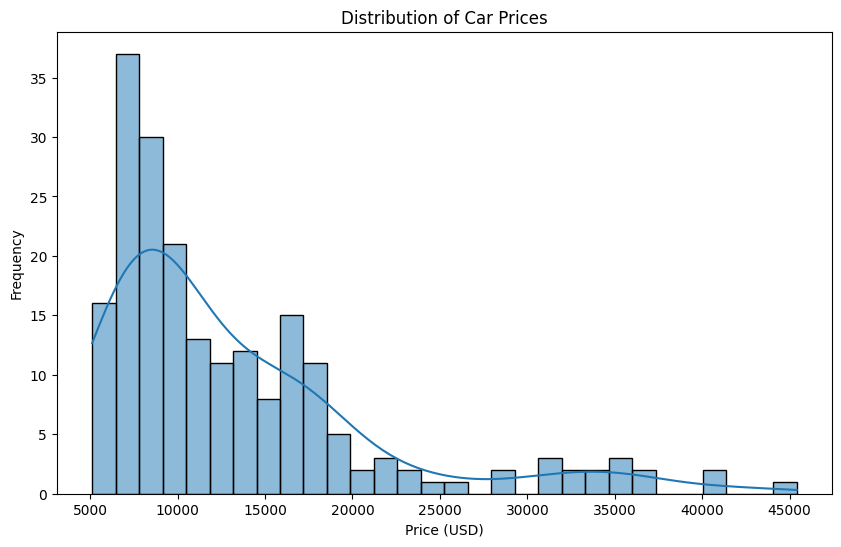

In [521]:
plt.figure(figsize=(10, 6))
sns.histplot(data_frame['price'], kde=True, bins=30)
plt.title('Distribution of Car Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

For Numerical Columns : 




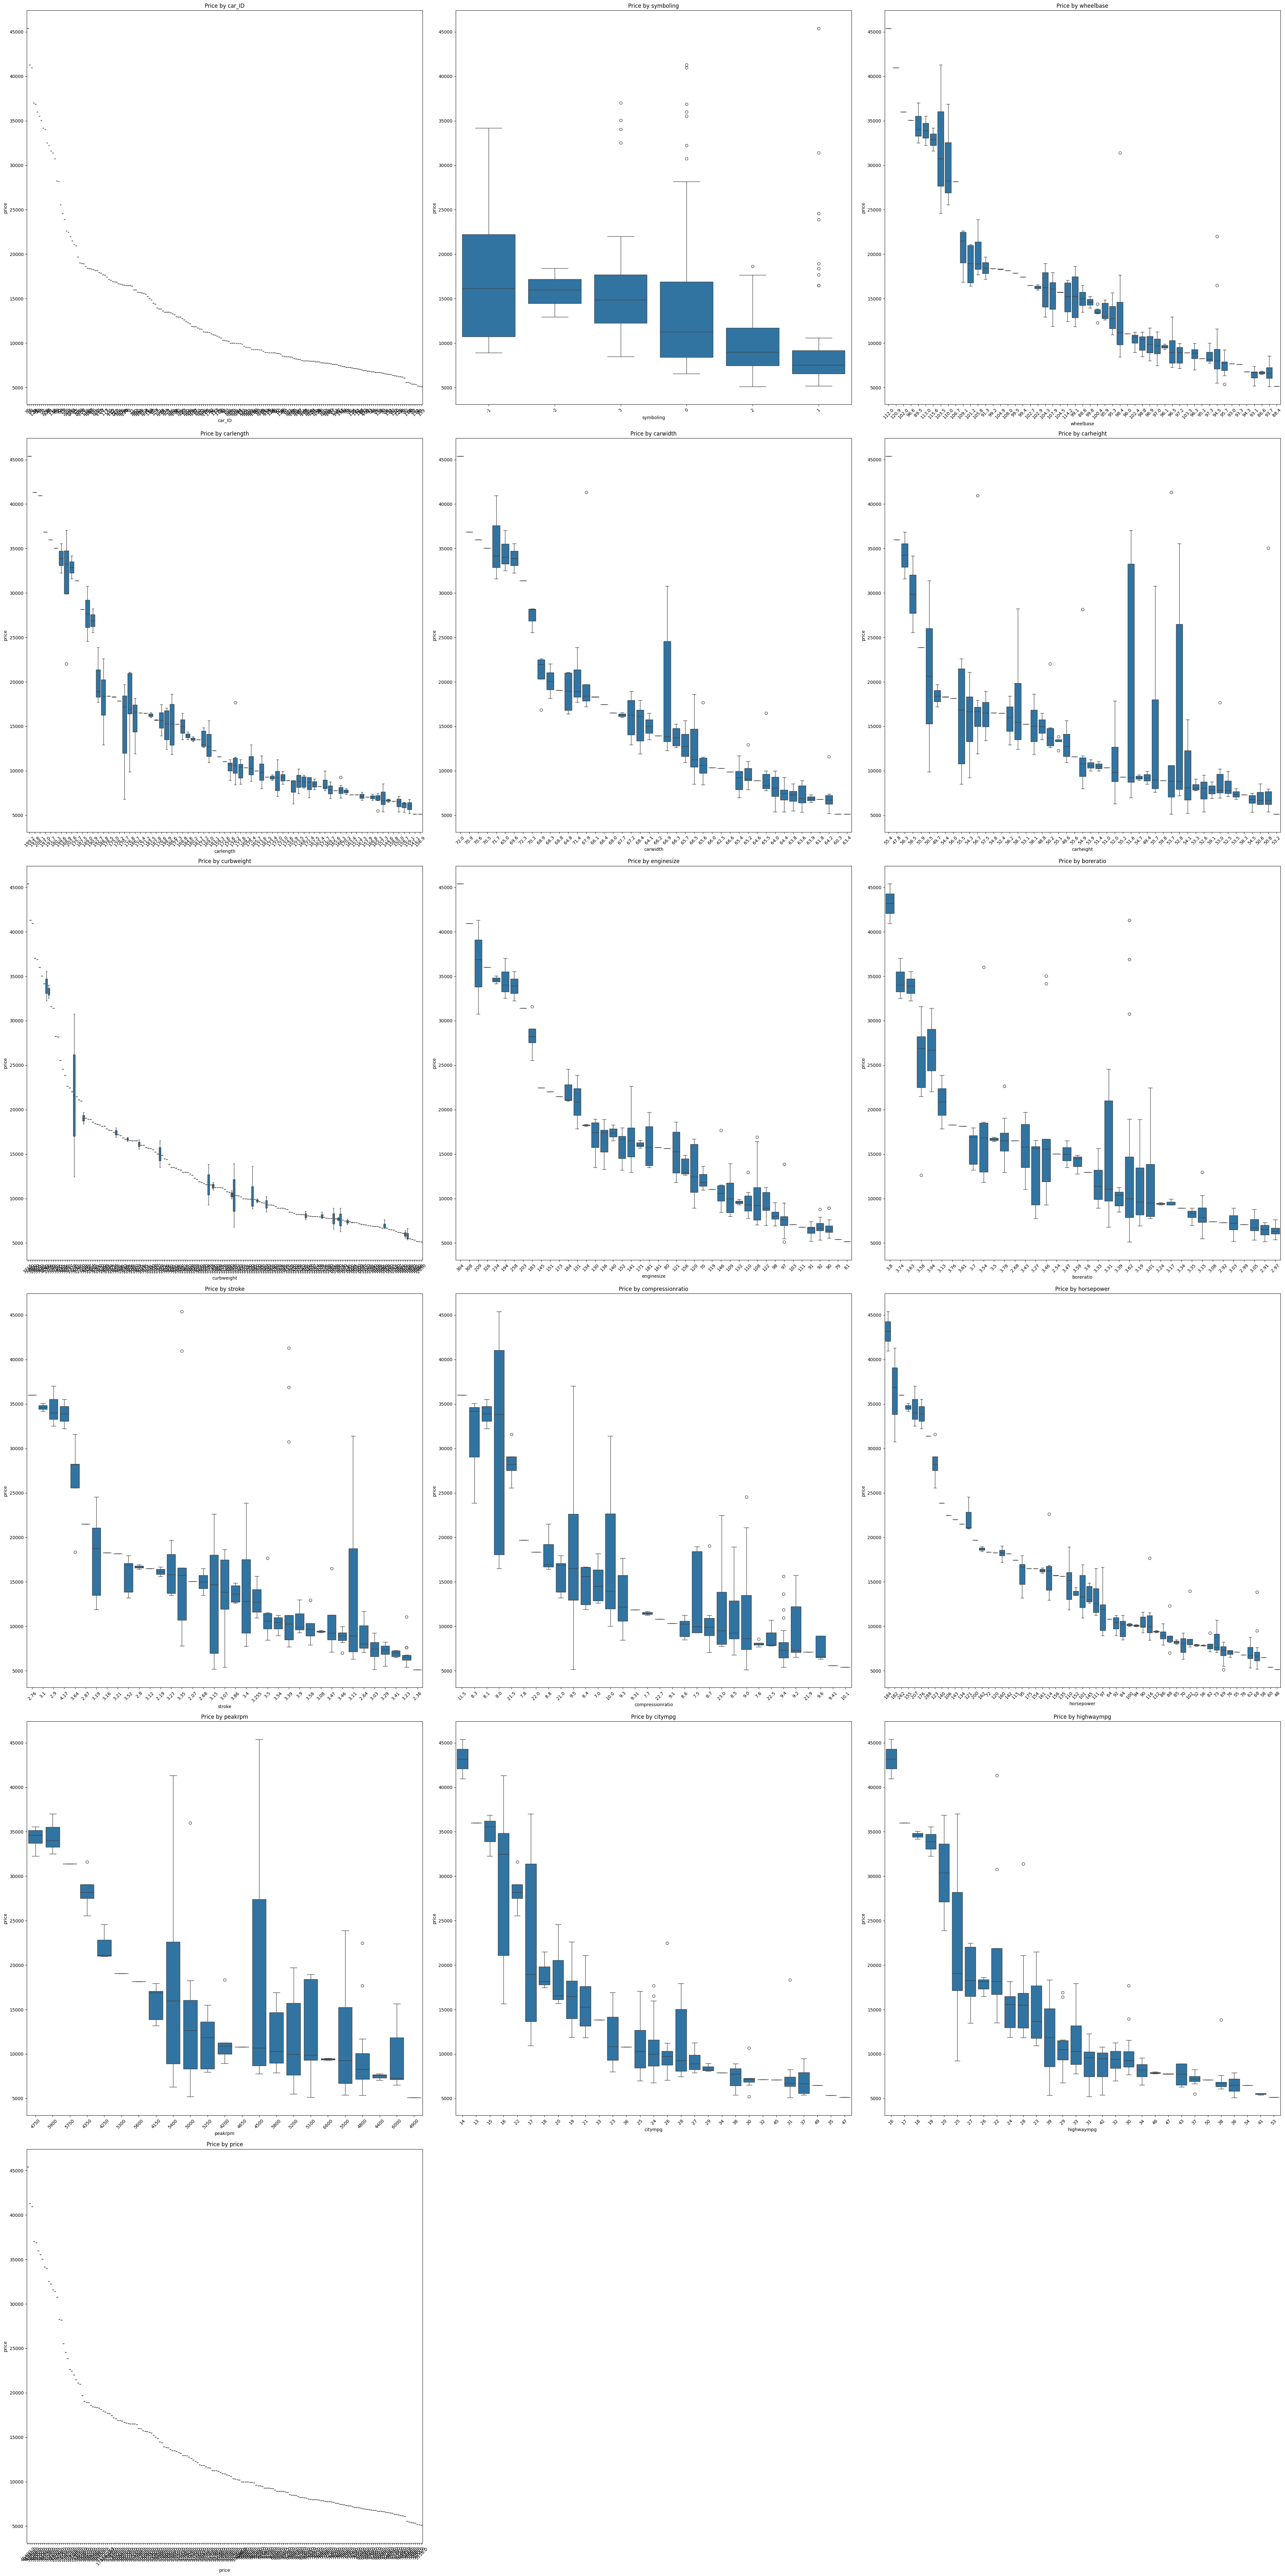





For Categorical Columns : 




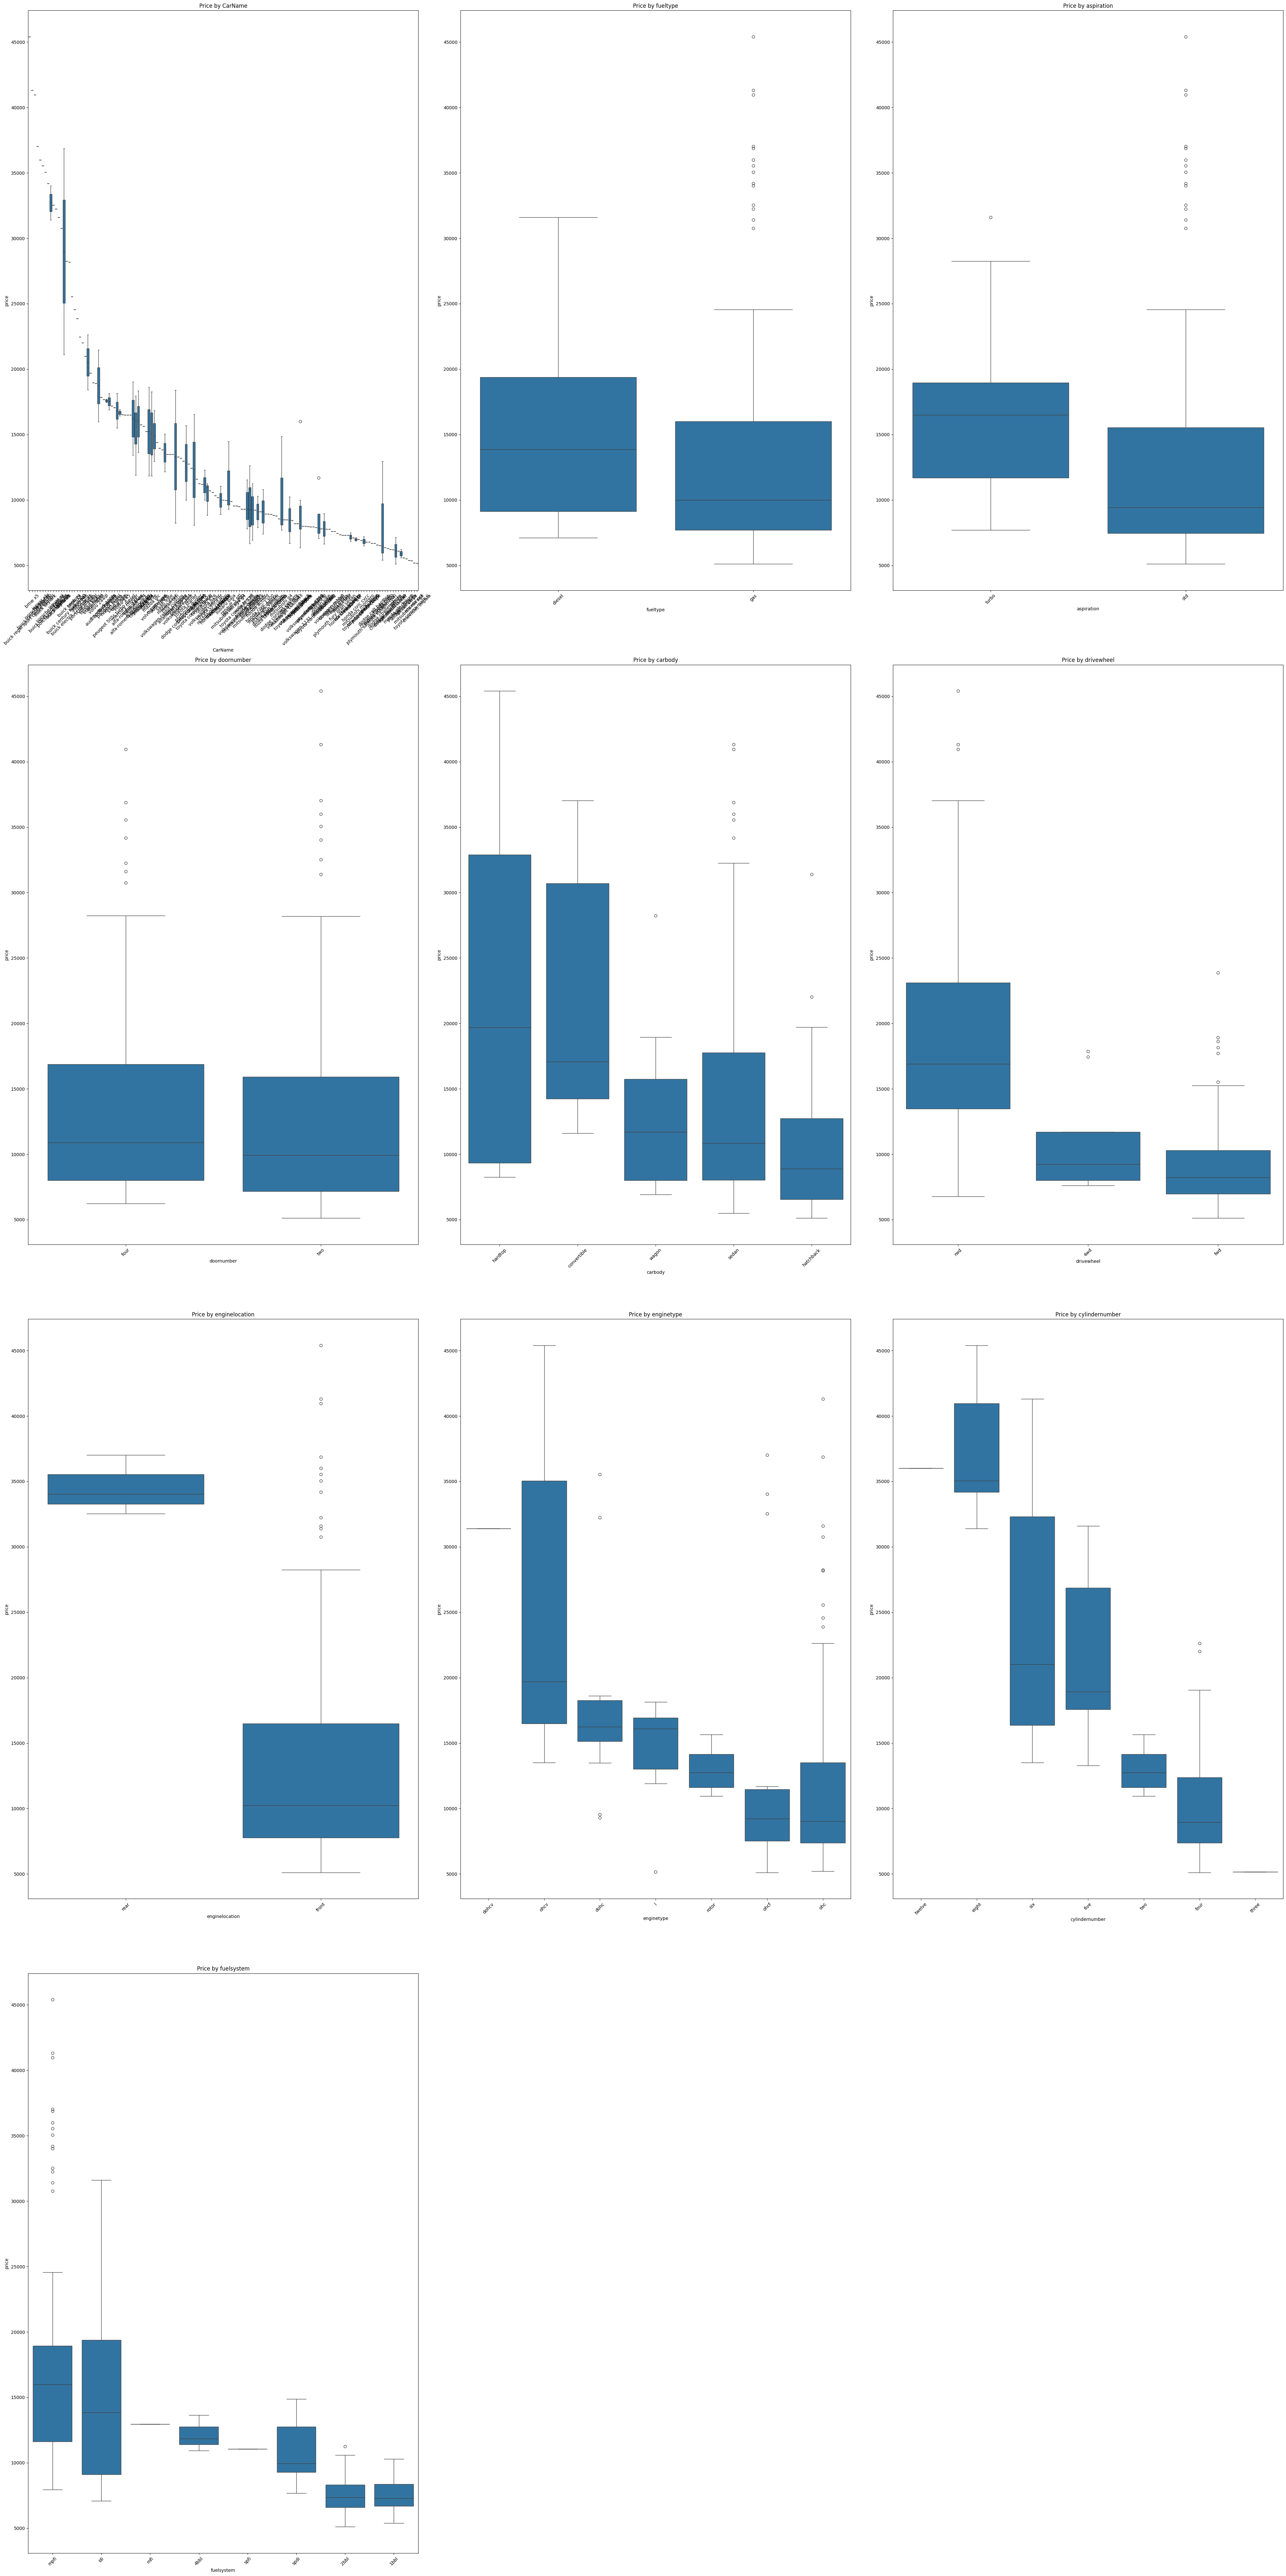

In [522]:
# Create a grid of box plots
def box_plot(data_columns):
  num_plots = len(data_columns)
  columns = 3
  rows = math.ceil(num_plots / columns)

  fig, axes = plt.subplots(rows, columns, figsize=(40, 80))
  axes = axes.ravel()

  for i, col in enumerate(data_columns):
      # Order by median price for better readability
      order = data_frame.groupby(col)['price'].median().sort_values(ascending=False).index
      sns.boxplot(data=data_frame, x=col, y='price', ax=axes[i], order=order)
      axes[i].set_title(f'Price by {col}')
      axes[i].tick_params(axis='x', rotation=45) # Rotate x labels for readability

  # Hide any empty subplots
  for j in range(i+1, len(axes)):
      fig.delaxes(axes[j])

  plt.tight_layout()
  plt.show()


print(f"For Numerical Columns : \n\n")
box_plot(NCs)
print(f"\n\n\n\nFor Categorical Columns : \n\n")
box_plot(CCs)

**For Numeric Columns / Features :**

HeatMap : To make correlation of the data

The relationship among all the column including the target column

<Axes: >

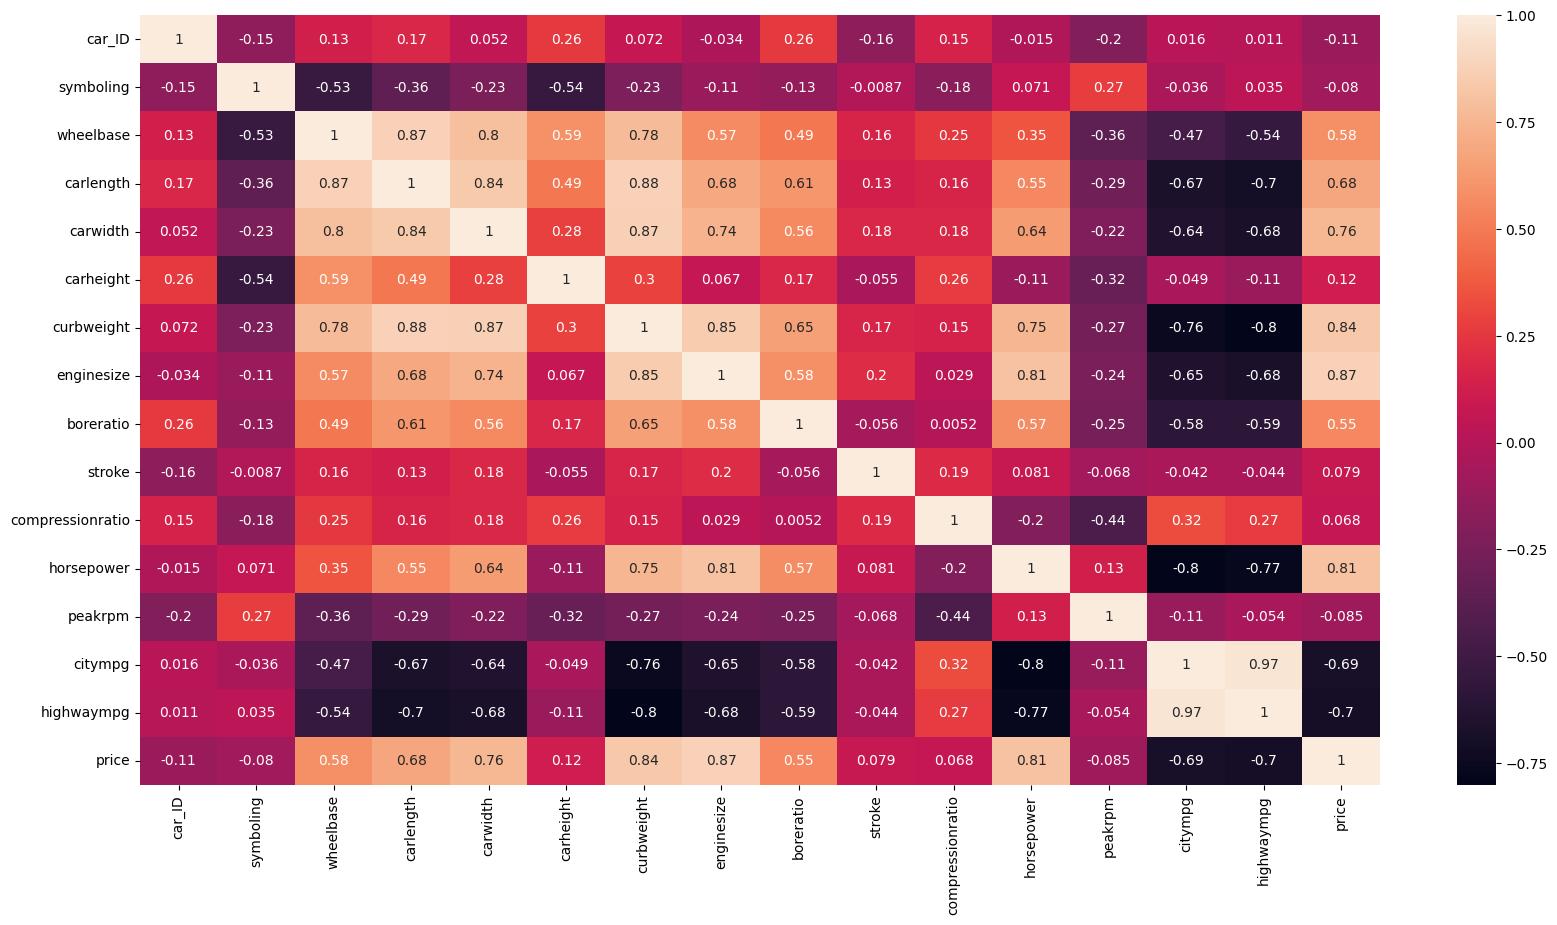

In [523]:
fig = plt.subplots(figsize=(20, 10))
sns.heatmap(data_frame[NCs].corr(),annot = True)

Scatter Plots & Correlation

['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']


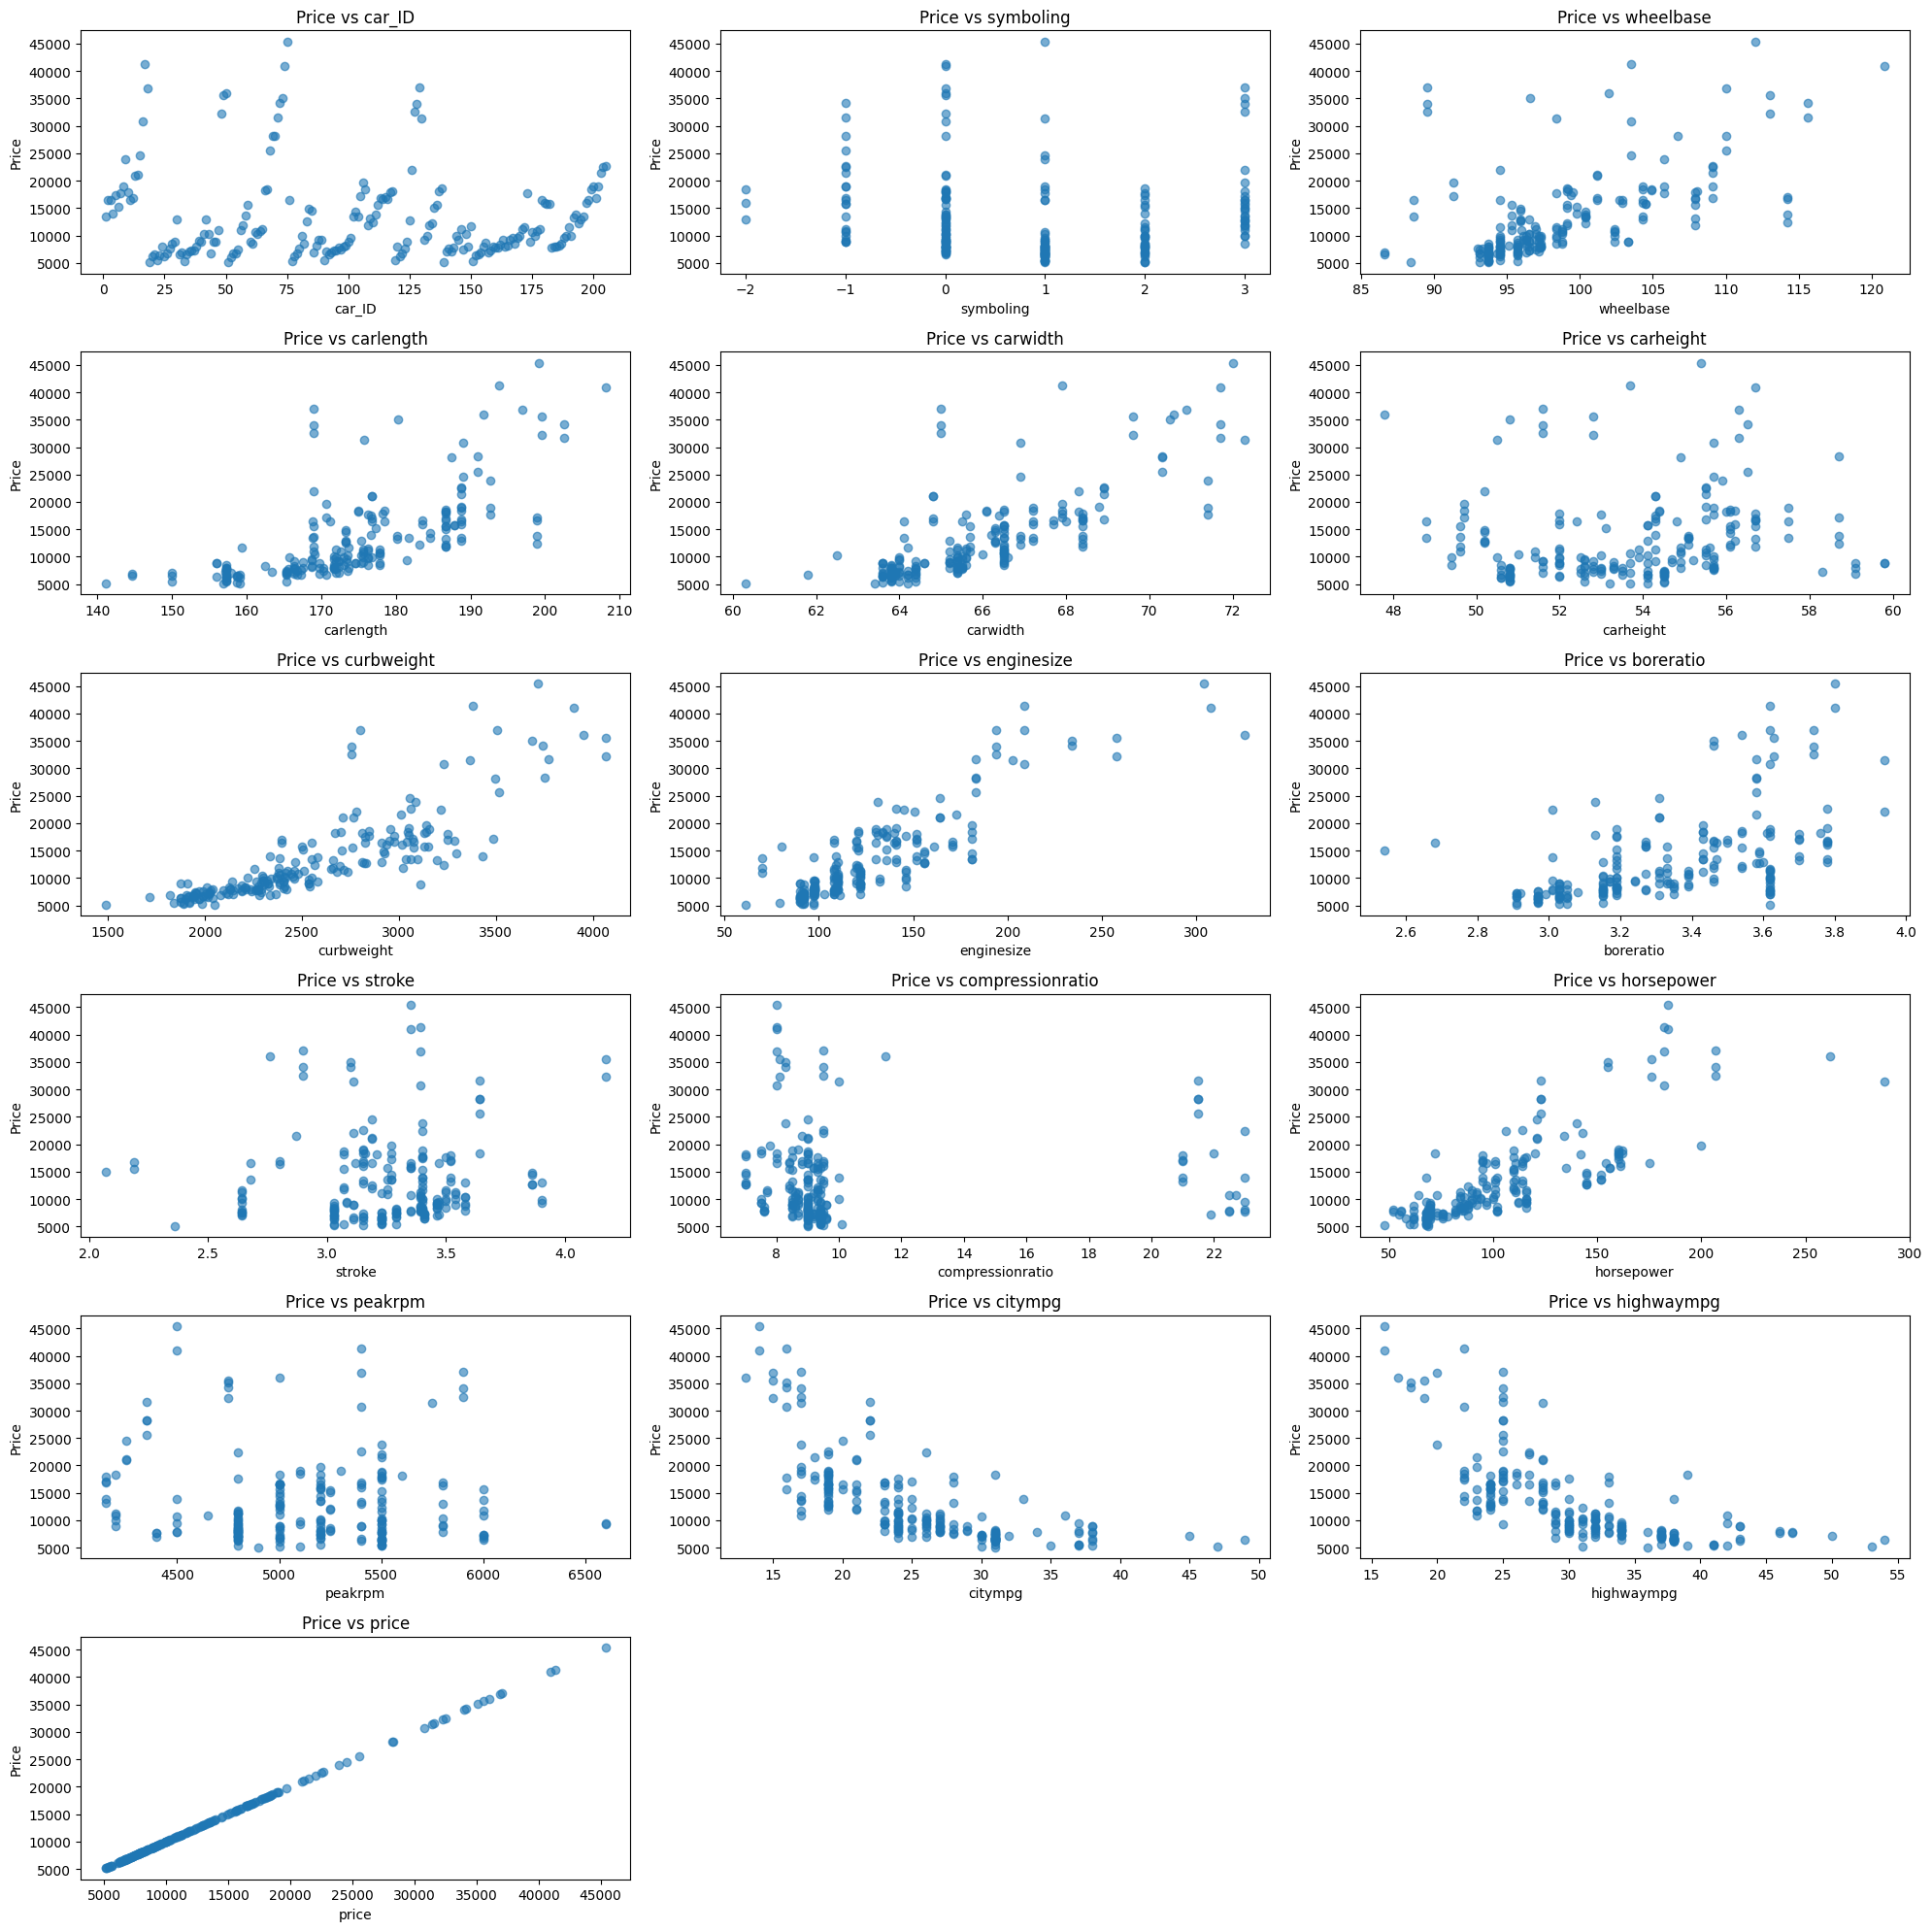

In [524]:
print(NCs)
# Create a grid of scatter plots
num_plots = len(NCs)
columns = 3
rows = math.ceil(num_plots / columns)
fig, axes = plt.subplots(rows, columns, figsize=(20, 20)) # 2 rows, 3 columns
axes = axes.ravel() # Flatten the array of axes

for i, col in enumerate(NCs):
    axes[i].scatter(data_frame[col], data_frame['price'], alpha=0.6)
    axes[i].set_title(f'Price vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')

# Hide any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**For Categorical Columns / Features :**

Count Plot :

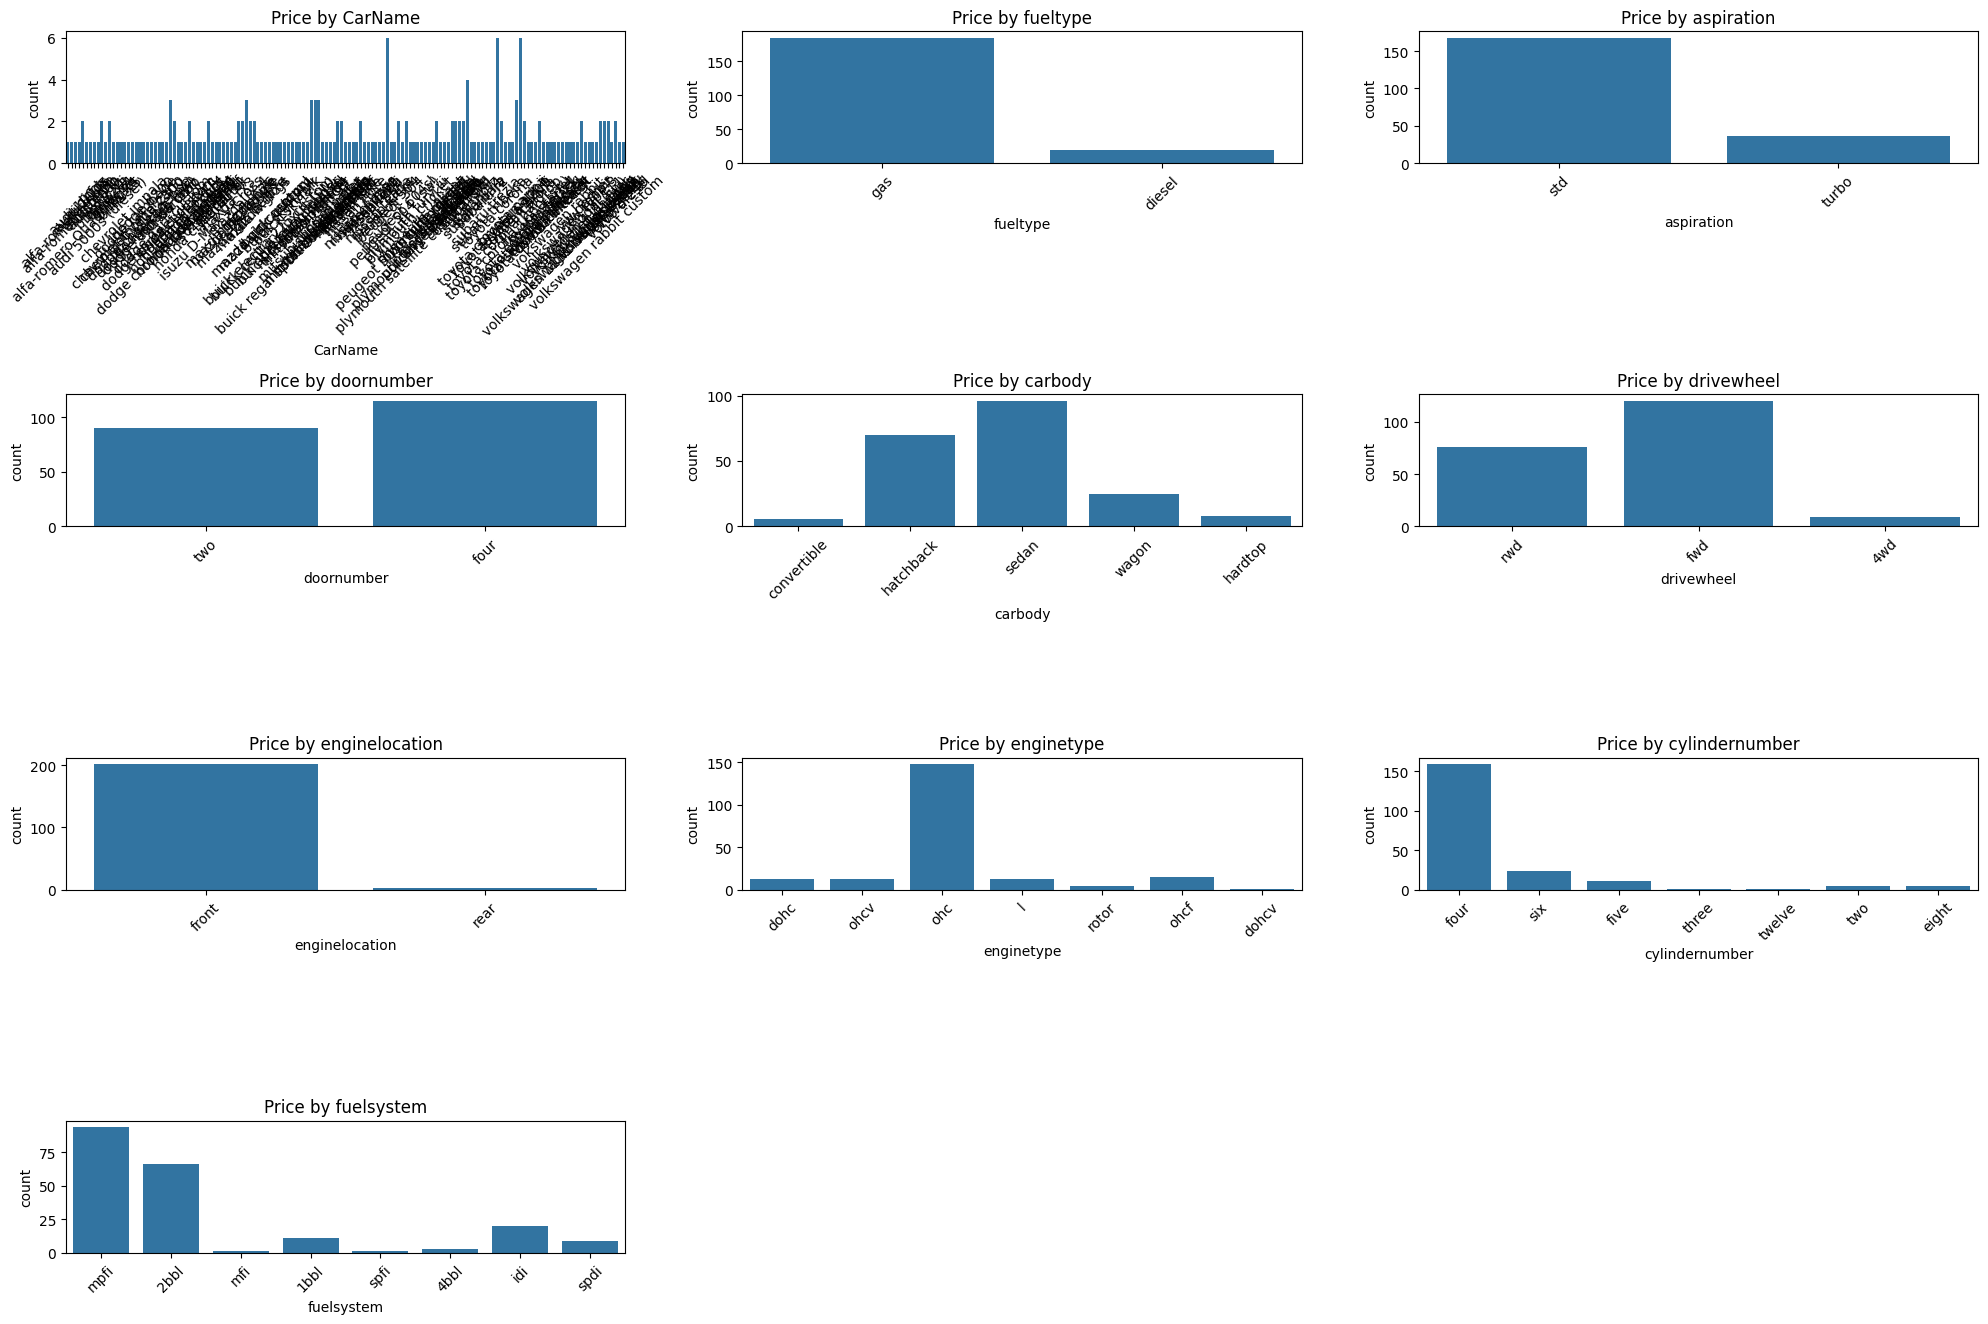

In [525]:
fig, axes = plt.subplots(rows, columns, figsize=(20, 20))
axes = axes.ravel()
for i, col in enumerate(CCs):
  sns.countplot(x = col, data=data_frame , ax = axes[i])
  axes[i].set_title(f'Price by {col}')
  axes[i].tick_params(axis='x', rotation=45) # Rotate x labels for readability

# Hide any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Make Preprocessing Techniques
- Convert Wrong Columns DataTypes (if needed) /
- Handle Nulls /
- Drop Duplicates /
- Handle Outliers /
- Feature Engineering (if needed)
- Feature Extraction (if needed)

In [526]:
for col in CCs :
  print(f"{col} Column has values : [ {data_frame[col].unique()} ] ")

"""
Column 'fueltype' has constant value: 1.0
[1.]
Column 'aspiration' has constant value: 1.0
[1.]
Column 'enginelocation' has constant value: 1.0
[1.]
Column 'enginetype' has constant value: 3.0
[3.]
Column 'cylindernumber' has constant value: 4.0
[4.]
"""

data_frame['fueltype'].replace({'gas' : 1, 'diesel' : 2}, inplace = True)
data_frame['aspiration'].replace({'std' : 1, 'turbo' : 2}, inplace = True)
data_frame['doornumber'].replace({'two': 2, 'four': 4}, inplace = True)
# carbody , enginetype , fuelsystem -> have lots of unique values [label encoding]
# drivewheel (3) can be one hot encoding or label encoding
data_frame['enginelocation'].replace({'front' : 1, 'rear' : 2}, inplace = True)
data_frame['drivewheel'].replace({'rwd' : 1, 'fwd' : 2,  '4wd' : 3 } , inplace = True)
data_frame['cylindernumber'].replace({'four': 4, 'six' : 6, 'five' : 5, 'three' : 3, 'twelve' : 12, 'two' : 2, 'eight' : 8}, inplace = True)


CarName Column has values : [ ['alfa-romero giulia' 'alfa-romero stelvio' 'alfa-romero Quadrifoglio'
 'audi 100 ls' 'audi 100ls' 'audi fox' 'audi 5000' 'audi 4000'
 'audi 5000s (diesel)' 'bmw 320i' 'bmw x1' 'bmw x3' 'bmw z4' 'bmw x4'
 'bmw x5' 'chevrolet impala' 'chevrolet monte carlo' 'chevrolet vega 2300'
 'dodge rampage' 'dodge challenger se' 'dodge d200' 'dodge monaco (sw)'
 'dodge colt hardtop' 'dodge colt (sw)' 'dodge coronet custom'
 'dodge dart custom' 'dodge coronet custom (sw)' 'honda civic'
 'honda civic cvcc' 'honda accord cvcc' 'honda accord lx'
 'honda civic 1500 gl' 'honda accord' 'honda civic 1300' 'honda prelude'
 'honda civic (auto)' 'isuzu MU-X' 'isuzu D-Max ' 'isuzu D-Max V-Cross'
 'jaguar xj' 'jaguar xf' 'jaguar xk' 'maxda rx3' 'maxda glc deluxe'
 'mazda rx2 coupe' 'mazda rx-4' 'mazda glc deluxe' 'mazda 626' 'mazda glc'
 'mazda rx-7 gs' 'mazda glc 4' 'mazda glc custom l' 'mazda glc custom'
 'buick electra 225 custom' 'buick century luxus (sw)' 'buick century'
 'bui

/tmp/ipython-input-1841545722.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_frame['fueltype'].replace({'gas' : 1, 'diesel' : 2}, inplace = True)
/tmp/ipython-input-1841545722.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_frame['fueltype'].replace({'gas' : 1, 'diesel' : 2}, in

**Encoding :**

In [527]:
# carbody , enginetype , fuelsystem -> have lots of unique values [label encoding]
# drivewheel
unlabeled_data = ['carbody' , 'enginetype' , 'fuelsystem' ,]

# Label Encoding :
lable_encoding = LabelEncoder()
print("After Encoding : \n")
for col in unlabeled_data:
  data_frame[col] = lable_encoding.fit_transform(data_frame[col])
  print(f"{col} Column")
  # print(data_frame[col])
  print(f"{data_frame[col].dtypes}\n")
  print(data_frame[col].unique())

After Encoding : 

carbody Column
int64

[0 2 3 4 1]
enginetype Column
int64

[0 5 3 2 6 4 1]
fuelsystem Column
int64

[5 1 4 0 7 2 3 6]


In [528]:
data_frame = data_frame.drop('CarName' , axis = 1)
CCs.remove('CarName')

In [529]:
print(data_frame.dtypes)

car_ID                int64
symboling             int64
fueltype              int64
aspiration            int64
doornumber            int64
carbody               int64
drivewheel            int64
enginelocation        int64
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype            int64
cylindernumber        int64
enginesize            int64
fuelsystem            int64
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object


**Handling Duplicates :**

In [530]:
data_frame.duplicated().sum()

np.int64(0)

**Handling Outliers :**

In [532]:
# Check for Number of Outliers for each column
total_outliers = 267
for i in data_frame.columns:
  # print(data_frame[i].dtypes)
  q1 = np.percentile(data_frame[i], 25)
  q3 = np.percentile(data_frame[i], 75)
  norm_range = (q3 - q1) * 1.5

  # Identify lower outliers
  lower_outliers = data_frame[data_frame[i] < (q1 - norm_range)]

  # Identify upper outliers
  upper_outliers = data_frame[data_frame[i] > (q3 + norm_range)]

  # Count the total number of outliers
  outliers = len(lower_outliers) + len(upper_outliers)
  total_outliers -= outliers

  print(f"The number of outliers in {i}: {outliers}")

  # Replace outliers with adjusted values
  data_frame[i] = np.where(data_frame[i] < (q1 - norm_range), q1 - norm_range, data_frame[i])
  data_frame[i] = np.where(data_frame[i] > (q3 + norm_range), q3 + norm_range, data_frame[i])

print(total_outliers)
# To Handle it :


  # 1 - Capping Outliers with IQR
  # data_frame[col] = np.where(data_frame[col] < lower_outliers, lower_outliers, np.where(data_frame[col] > upper_outliers, upper_outliers, data_frame[col]))

  # 2 - Remove Outliers
  # data_frame = data_frame[(data_frame[col] >= lower_outliers) & (data_frame[col] <= upper_outliers)]

  # 3 - Imputation ( Replacing with mean or median )
  # median = data_frame[col].median()
  # data_frame.loc[data_frame[col] < lower_outliers, col] = median
  # data_frame.loc[data_frame[col] > upper_outliers, col] = median

# for col in NCs:
#   plt.figure(figsize=(6,3))
#   sns.boxplot(x=data_frame[col])
#   plt.title(f"Boxplot of {col}")
#   plt.show()

The number of outliers in car_ID: 0
The number of outliers in symboling: 0
The number of outliers in fueltype: 20
The number of outliers in aspiration: 37
The number of outliers in doornumber: 0
The number of outliers in carbody: 6
The number of outliers in drivewheel: 0
The number of outliers in enginelocation: 3
The number of outliers in wheelbase: 3
The number of outliers in carlength: 1
The number of outliers in carwidth: 8
The number of outliers in carheight: 0
The number of outliers in curbweight: 0
The number of outliers in enginetype: 57
The number of outliers in cylindernumber: 46
The number of outliers in enginesize: 10
The number of outliers in fuelsystem: 0
The number of outliers in boreratio: 0
The number of outliers in stroke: 20
The number of outliers in compressionratio: 28
The number of outliers in horsepower: 6
The number of outliers in peakrpm: 2
The number of outliers in citympg: 2
The number of outliers in highwaympg: 3
The number of outliers in price: 15
0


**Feature Selection :**

In [533]:
#knowing how many columns have high or low or bad correlation
high_corr = []
low_corr = []
bad_corr = []
for col in data_frame.columns:
  relation = data_frame['price'].corr(data_frame[col])
  if(relation > 0):
    if relation >= 0.7 and relation <= 1 :
      # print(f"relation between {col} & diagnosis is high positive \n {relation}")
      high_corr.append(col)
    elif relation >= 0.4 and relation < 0.7 :
      # print(f"relation between {col} & diagnosis is low positive \n {relation}")
      low_corr.append(col)
    else: bad_corr.append(col)# print(f"relation between {col} & diagnosis is very low positive \n {relation}")
  else:
    if relation <= -0.7 and relation > -1 :
      # print(f"relation between {col} & diagnosis is high negative \n {relation}")
      high_corr.append(col)
    elif relation <= -0.4 and relation > -0.7 :
      # print(f"relation between {col} & diagnosis is low negative \n {relation}")
      low_corr.append(col)
    else: bad_corr.append(col)# print(f"relation between {col} & diagnosis is very low negative \n {relation}")

print(f"the high corr are {high_corr}")
print(f"the low corr are {low_corr}")
print(f"the bad corr are {bad_corr}")


# removed_columns = ['car_ID', 'symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'enginelocation', 'carheight', 'enginetype', 'cylindernumber', 'stroke', 'compressionratio', 'peakrpm']
# for col in removed_columns:
#   data_frame = data_frame.drop(col, axis=1)
#   print(f"{col} Column has been removed.")

correlation_matrix = data_frame.corr(numeric_only=True)
constant_columns = []
for col in data_frame.columns:
    if data_frame[col].nunique() == 1:
        constant_columns.append(col)
        print(f"Column '{col}' has constant value: {data_frame[col].iloc[0]}")
        print(data_frame[col].unique())
print(correlation_matrix['price'].sort_values(ascending=False))

the high corr are ['carlength', 'carwidth', 'curbweight', 'enginesize', 'horsepower', 'citympg', 'highwaympg', 'price']
the low corr are ['drivewheel', 'wheelbase', 'fuelsystem', 'boreratio']
the bad corr are ['car_ID', 'symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'enginelocation', 'carheight', 'enginetype', 'cylindernumber', 'stroke', 'compressionratio', 'peakrpm']
Column 'fueltype' has constant value: 1.0
[1.]
Column 'aspiration' has constant value: 1.0
[1.]
Column 'enginelocation' has constant value: 1.0
[1.]
Column 'enginetype' has constant value: 3.0
[3.]
Column 'cylindernumber' has constant value: 4.0
[4.]
price               1.000000
curbweight          0.864597
enginesize          0.860063
horsepower          0.821715
carwidth            0.783230
carlength           0.712455
wheelbase           0.595909
boreratio           0.572685
fuelsystem          0.570273
carheight           0.142033
stroke              0.073830
doornumber          0.061434
carbody      

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


**Feature Engineering :**

In [534]:
# data_frame['car_volume'] = data_frame['carlength'] * data_frame['carwidth'] * data_frame['carheight']
# data_frame['aspect_ratio'] = data_frame['carlength'] / data_frame['carwidth']

# data_frame['stroke_bore_ratio'] = data_frame['stroke'] / data_frame['boreratio']

# data_frame['avg_mpg'] = (data_frame['citympg'] + data_frame['highwaympg']) / 2
# data_frame['mileage_difference'] = data_frame['highwaympg'] - data_frame['citympg']

## Split Data

In [535]:
features = data_frame.drop(columns=['price'])
target = data_frame['price']

In [536]:
f_train , f_test , t_train , t_test = train_test_split(features , target , test_size=0.2 , random_state=1)

## Make Encoding & Scaling IF Needed

I will need to make enconding before make a feature selection to see the relation between all features and output then choose what is useful

In [537]:
SS = StandardScaler()

f_train_ss = SS.fit_transform(f_train)
f_test_ss = SS.transform(f_test)

MMS = MinMaxScaler()

f_train_mms = MMS.fit_transform(f_train)
f_test_mms = MMS.transform(f_test)

## Import Linear Regression Model

In [538]:
LRM_SS = LinearRegression()
LRM_MMS = LinearRegression()

## Add Regularizations Terms (if needed)

In [575]:
lasso_ss = Lasso(alpha=0.2)
lasso_mms = Lasso(alpha=0.2)

ridge_ss = Ridge(alpha=2.0)
ridge_mms = Ridge(alpha=2.0)

## Train Model

In [576]:
LRM_SS.fit(f_train_ss , t_train)
LRM_MMS.fit(f_train_mms , t_train)

lasso_ss.fit(f_train_ss , t_train)
lasso_mms.fit(f_train_mms , t_train)

ridge_ss.fit(f_train_ss , t_train)
ridge_mms.fit(f_train_mms , t_train)

Ridge(alpha=2.0)

## Evaluate Model:
- MSE
- MAE
- R2_Score

In [577]:
def EvaluateModel(text , y_pred_train , y_train):
  print(text)
  print("MSE:",metrics.mean_squared_error(y_pred_train,y_train))
  print("MAE:",metrics.mean_absolute_error(y_pred_train,y_train))
  print("RMSE:",np.sqrt(metrics.mean_squared_error(y_pred_train,y_train)))
  print("r2_score:",metrics.r2_score(y_pred_train,y_train))

In [578]:
t_predict_train_ss = LRM_SS.predict(f_train_ss)
t_predict_test_ss = LRM_SS.predict(f_test_ss)

t_predict_train_mms = LRM_MMS.predict(f_train_mms)
t_predict_test_mms = LRM_MMS.predict(f_test_mms)

In [579]:
EvaluateModel("Linear Regression Model Using Standard Scalar (Train Data): \n" , t_predict_train_ss , t_train)
EvaluateModel("Linear Regression Model Using Standard Scalar (Test Data): \n" , t_predict_test_ss , t_test)

Linear Regression Model Using Standard Scalar (Train Data): 

MSE: 5383148.528702095
MAE: 1771.9308309343278
RMSE: 2320.161315232649
r2_score: 0.8675366098310069
Linear Regression Model Using Standard Scalar (Test Data): 

MSE: 4844179.094079695
MAE: 1772.0356622118645
RMSE: 2200.9495891727493
r2_score: 0.8397789190169191


In [580]:
EvaluateModel("Linear Regression Model Using Min Max Scalar (Train Data): \n" , t_predict_train_mms , t_train)
EvaluateModel("Linear Regression Model Using Min Max Scalar (Test Data): \n" , t_predict_test_mms , t_test)

Linear Regression Model Using Min Max Scalar (Train Data): 

MSE: 5383148.528702095
MAE: 1771.9308309343278
RMSE: 2320.161315232649
r2_score: 0.8675366098310067
Linear Regression Model Using Min Max Scalar (Test Data): 

MSE: 4844179.094079701
MAE: 1772.0356622118663
RMSE: 2200.949589172751
r2_score: 0.8397789190169185


In [581]:
t_predict_train_lasso_ss = lasso_ss.predict(f_train_ss)
t_predict_test_lasso_ss = lasso_ss.predict(f_test_ss)

t_predict_train_lasso_mms = lasso_mms.predict(f_train_mms)
t_predict_test_lasso_mms = lasso_mms.predict(f_test_mms)

In [582]:
EvaluateModel("Linear Regression Model With Lasso Using Standard Scalar (Train Data): \n" , t_predict_train_lasso_ss , t_train)
EvaluateModel("Linear Regression Model With Lasso Using Standard Scalar (Test Data): \n" , t_predict_test_lasso_ss , t_test)

Linear Regression Model With Lasso Using Standard Scalar (Train Data): 

MSE: 5383153.536681349
MAE: 1771.8284312635196
RMSE: 2320.16239446323
r2_score: 0.8675151781218597
Linear Regression Model With Lasso Using Standard Scalar (Test Data): 

MSE: 4841889.383714646
MAE: 1771.7312576427832
RMSE: 2200.4293634912815
r2_score: 0.8398656750546043


In [583]:
EvaluateModel("Linear Regression Model With Lasso Using Min Max Scalar (Train Data): \n" , t_predict_train_lasso_mms , t_train)
EvaluateModel("Linear Regression Model With Lasso Using Min Max Scalar (Test Data): \n" , t_predict_test_lasso_mms , t_test)

Linear Regression Model With Lasso Using Min Max Scalar (Train Data): 

MSE: 5383275.054510289
MAE: 1771.5767117180776
RMSE: 2320.1885816696645
r2_score: 0.8674417799378868
Linear Regression Model With Lasso Using Min Max Scalar (Test Data): 

MSE: 4832880.81503862
MAE: 1770.3537497633806
RMSE: 2198.381407999672
r2_score: 0.8402179388045652


In [584]:
t_predict_train_ridge_ss = ridge_ss.predict(f_train_ss)
t_predict_test_ridge_ss = ridge_ss.predict(f_test_ss)

t_predict_train_ridge_mms = ridge_mms.predict(f_train_mms)
t_predict_test_ridge_mms = ridge_mms.predict(f_test_mms)

In [585]:
EvaluateModel("Linear Regression Model With Ridge Using Standard Scalar (Train Data): \n" , t_predict_train_ridge_ss , t_train)
EvaluateModel("Linear Regression Model With Ridge Using Standard Scalar (Test Data): \n" , t_predict_test_ridge_ss , t_test)

Linear Regression Model With Ridge Using Standard Scalar (Train Data): 

MSE: 5397740.0325803645
MAE: 1767.4477148180968
RMSE: 2323.303689271027
r2_score: 0.8656054257894069
Linear Regression Model With Ridge Using Standard Scalar (Test Data): 

MSE: 4714239.360930446
MAE: 1752.3894459319536
RMSE: 2171.2299189469654
r2_score: 0.8443277789474901


In [586]:
EvaluateModel("Linear Regression Model With Ridge Using Min Max Scalar (Train Data): \n" , t_predict_train_ridge_mms , t_train)
EvaluateModel("Linear Regression Model With Ridge Using Min Max Scalar (Test Data): \n" , t_predict_test_ridge_mms , t_test)

Linear Regression Model With Ridge Using Min Max Scalar (Train Data): 

MSE: 6032163.998856717
MAE: 1830.2579875081074
RMSE: 2456.046416266744
r2_score: 0.831981610860208
Linear Regression Model With Ridge Using Min Max Scalar (Test Data): 

MSE: 4388430.310685226
MAE: 1648.0708923987254
RMSE: 2094.858064567914
r2_score: 0.8544458188756097
